In [1]:


import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import DecayFitNet.python.toolbox.BayesianDecayAnalysis as bda

from config.config import Config
from slope2noise.rir_synthesis import rir_synthesis
from slope2noise.utils import decay_kernel, schroeder_backward_int, db, save_audio, calculate_amplitudes_least_squares, octave_filtering

In [2]:
T_s = np.array([[0.5, 1.5]])  # T60 in seconds
A_s = np.array([1, 0.01])   # decay model amplitude (energy)
n_slopes = T_s.shape[-1]
fs = 48000  # sampling frequency in Hz
L = 3*fs   # length of the impulse response in samples

time_axis = np.arange(0, L) / fs

### Energy Decay Curve 

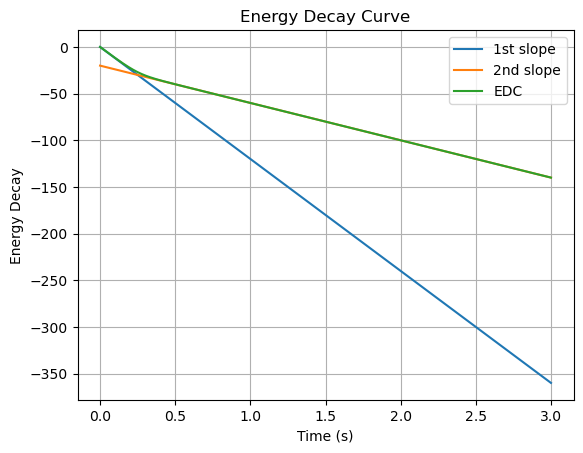

In [3]:
envelope_kernel = decay_kernel( T_s,
                                time_axis,
                                fs,
                                normalise_envelope=False,
                                add_noise=False)
edc = A_s*envelope_kernel
plt.plot(time_axis, 10*np.log10(edc[0, :, 0]), label='1st slope')
plt.plot(time_axis, 10*np.log10(edc[0, :, 1]), label='2nd slope')
plt.plot(time_axis, 10*np.log10(np.sum(edc[0, :, :], axis=-1)), label='EDC')
plt.xlabel('Time (s)')
plt.ylabel('Energy Decay')
plt.legend()
plt.title('Energy Decay Curve')
plt.grid(True)
plt.show()

### Shaped Noise

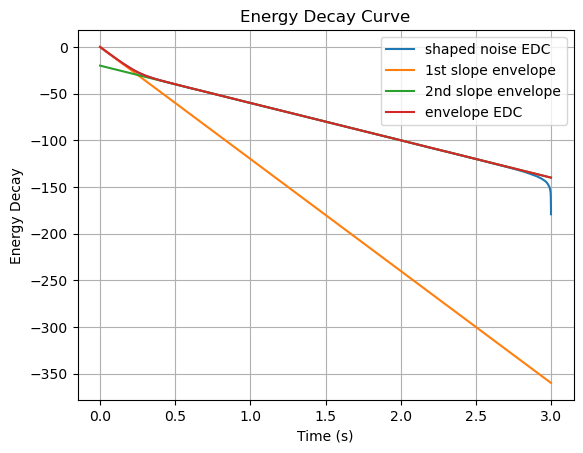

In [4]:
T_e = 2 * T_s
A_e = np.sqrt(A_s) * np.sqrt(1-np.exp(-np.log(1e6)/fs/T_s))
envelope_kernel = decay_kernel( T_e,
                                time_axis,
                                fs,
                                normalise_envelope=False,
                                add_noise=False)
gaussian_noise = np.random.randn(1, L, n_slopes)
shaped_noise = A_e*envelope_kernel*gaussian_noise
# use schroeder backward integration to get the EDC
sn_int = schroeder_backward_int(np.sum(shaped_noise, axis=-1), normalize=False)
plt.plot(time_axis, 10*np.log10(sn_int[0, :]), label='shaped noise EDC')
plt.plot(time_axis, 10*np.log10(edc[0, :, 0]), label='1st slope envelope')
plt.plot(time_axis, 10*np.log10(edc[0, :, 1]), label='2nd slope envelope')
plt.plot(time_axis, 10*np.log10(np.sum(edc[0, :, :], axis=-1)), label='envelope EDC')
plt.xlabel('Time (s)')
plt.ylabel('Energy Decay')
plt.legend()
plt.title('Energy Decay Curve')
plt.grid(True)
plt.show()

### Energy Decay Analysis

In [5]:
A_ls = calculate_amplitudes_least_squares(
    T_s,
    fs,
    np.sum(shaped_noise, axis=-1, keepdims=True),
    f_bands=None,
    leave_out_ms=50.0,
)

BDA = bda.BayesianDecayAnalysis(n_slopes,
                                fs,
                                filter_frequencies=None, )

edc_param, norm_vals = BDA.estimate_parameters(np.sum(shaped_noise, axis=-1))
# BDA takes the EDC parameters estimates for each band
T, A, N = edc_param[0], edc_param[1], edc_param[2]
# amplitudes with least squares
print(norm_vals)
print(
    f"Estimated T_BDA: {np.median(np.squeeze(np.round(T, 3)), axis=0)}, A_BDA: {np.median(np.squeeze(np.round(A, 3)*np.transpose(norm_vals)),axis=0)}" \
    f"Estimated A_LS: {np.squeeze(np.round(A_ls, 3))}" \
    f"  - Reference T: {np.squeeze(np.round(T_s, 3))}, A: {np.squeeze(np.round(A_s, 3))}"
)


[[0.00227504 0.00577733 0.01488382 0.0301271  0.05992809 0.13252749]]
Estimated T_BDA: [0.529 1.319], A_BDA: [0.01968038 0.00053225]Estimated A_LS: [0.722 0.01 ]  - Reference T: [0.5 1.5], A: [1.   0.01]


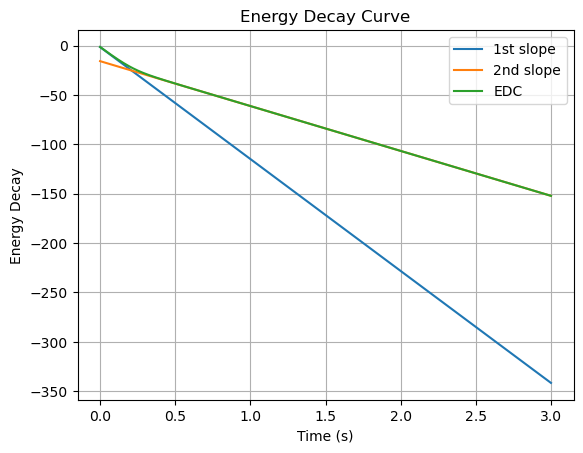

In [6]:
envelope_kernel = decay_kernel( np.median(np.squeeze(np.round(T, 3)), axis=0).reshape(1, -1),
                                time_axis,
                                fs,
                                normalise_envelope=False,
                                add_noise=False)
edc = np.median(np.squeeze(np.round(A, 3)),axis=0) * envelope_kernel
plt.plot(time_axis, 10*np.log10(edc[0, :, 0]), label='1st slope')
plt.plot(time_axis, 10*np.log10(edc[0, :, 1]), label='2nd slope')
plt.plot(time_axis, 10*np.log10(np.sum(edc[0, :, :], axis=-1)), label='EDC')
plt.xlabel('Time (s)')
plt.ylabel('Energy Decay')
plt.legend()
plt.title('Energy Decay Curve')
plt.grid(True)
plt.show()